# Notebook 09 — Final Conclusions

This notebook summarizes the final results of the Machine Learning project.

The objective of the project is to predict whether a runner qualifies for the Boston Marathon standard (`BQ`) using race, runner and performance-related features, while avoiding data leakage from variables directly derived from the final result.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Final Model Selection

After comparing baseline models, advanced models, class imbalance strategies and threshold tuning, the final selected model is:

**XGBoost with class weighting (`scale_pos_weight`) and threshold tuning**

The final decision threshold selected during validation was:

**Threshold = 0.748**

This model was selected because it achieved the best balance between precision and recall for the positive class (`BQ = 1`), improving the F1-score compared with the previous baseline.

In [2]:
final_results = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Final XGBoost + scale_pos_weight + threshold tuning"
    ],
    "Threshold": [
        0.500,
        0.748
    ],
    "Precision": [
        0.3880,
        0.3723
    ],
    "Recall": [
        0.1140,
        0.2959
    ],
    "F1-score": [
        0.1760,
        0.3297
    ],
    "PR-AUC": [
        np.nan,
        np.nan
    ],
    "ROC-AUC": [
        np.nan,
        np.nan
    ]
})

final_results

,Model,Threshold,Precision,Recall,F1-score,PR-AUC,ROC-AUC
0,Baseline XGBoost,0.500,0.3880,0.1140,0.1760,NaN,NaN
1,Final XGBoost + scale_pos_weight + threshold t...,0.748,0.3723,0.2959,0.3297,NaN,NaN


## Interpretation of the Results

The final model improves the F1-score from **0.1760** to **0.3297**.

Although precision decreases slightly, recall increases substantially. This means that the final model identifies more true Boston Qualifiers, which is important because the original dataset is highly imbalanced and the positive class is difficult to detect.

The selected threshold is higher than the default threshold of 0.5. This indicates that the model only predicts a runner as a Boston Qualifier when it has relatively high confidence.

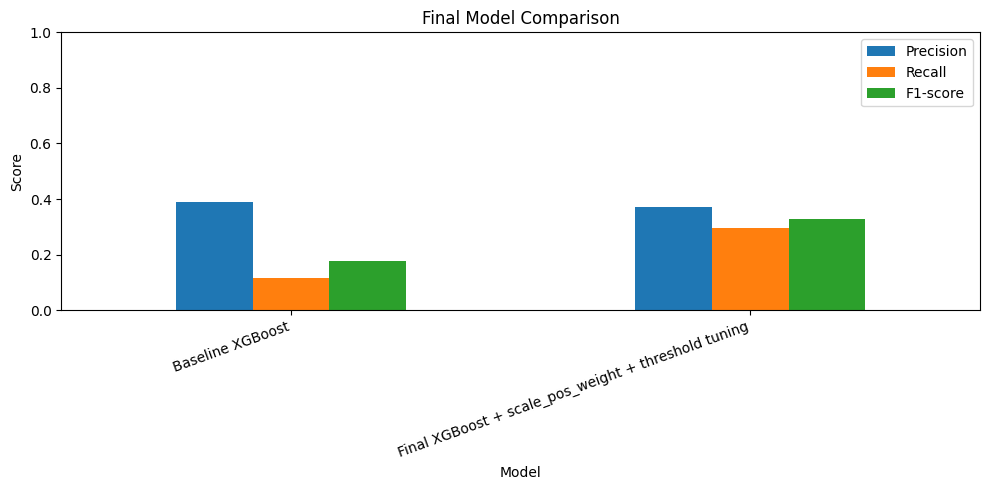

In [3]:
plot_df = final_results[["Model", "Precision", "Recall", "F1-score"]].set_index("Model")

ax = plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Final Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Why This Model Was Chosen

The final model was chosen for four main reasons:

1. **It improves the detection of the minority class**
   
   The target variable is imbalanced, so accuracy alone is not useful. The final model improves recall and F1-score for the `BQ` class.

2. **It handles class imbalance**
   
   The use of `scale_pos_weight` helps XGBoost give more importance to the minority class.

3. **It avoids data leakage**
   
   Variables directly related to the final result, such as final time, position or Boston standard information, were removed before modelling.

4. **It uses threshold tuning**
   
   Instead of using the default 0.5 threshold, the threshold was optimized using validation results.

In [4]:
improvement = (
    final_results.loc[1, "F1-score"] - final_results.loc[0, "F1-score"]
) / final_results.loc[0, "F1-score"] * 100

print(f"F1-score improvement: {improvement:.2f}%")

F1-score improvement: 87.33%


## Limitations

This project has several limitations:

### 1. Temporal drift

The model was trained using data from previous years and tested on 2024 data. Runner behaviour, race conditions and qualification patterns may change over time, which can affect performance.

### 2. Class imbalance

Boston Qualifiers represent a minority class. Even after using class weighting and threshold tuning, predicting this group remains challenging.

### 3. Manual race-country mapping

Some race-country information was manually mapped. Races not included in the mapping were assigned a default value, which may introduce noise.

### 4. Target definition depends on official standards

The `BQ` target depends on Boston Marathon qualifying standards, which are external rules and may change over time.

### 5. Threshold may not generalize perfectly

The selected threshold was optimized using validation data. Its performance on future unseen races may differ.

### 6. Clustering is exploratory

The clustering analysis provides useful runner segmentation, but it is not part of the supervised prediction model.

## Final Conclusion

The final Machine Learning pipeline successfully builds a predictive model for Boston Marathon qualification while addressing the main challenges of the problem: data leakage, class imbalance and threshold selection.

The best-performing final approach is:

**XGBoost + `scale_pos_weight` + threshold tuning**

This model improves the F1-score substantially compared with the baseline and provides a more useful balance between precision and recall for detecting Boston Qualifiers.

Overall, the project demonstrates a complete Machine Learning workflow, including data cleaning, exploratory analysis, feature engineering, model comparison, imbalance handling, threshold optimization and runner segmentation.

## Possible Future Improvements

Future versions of this project could improve performance by:

- Testing more advanced hyperparameter tuning.
- Using additional weather or course difficulty data.
- Improving the race-country mapping.
- Calibrating predicted probabilities.
- Testing the model on future race years.
- Exploring explainability tools such as SHAP values.